In [1]:
import lightning as L
import torch
import  random
import numpy as np

torch.set_float32_matmul_precision('high')
L.seed_everything(42, workers=True)      # разом: random, numpy, torch + воркеры

Seed set to 42


42

In [2]:
# пути
BACKGROUNDS_DIR = "/home/user/Documents/rust-items-detection/backgrounds"
ITEMS_DIR = "/home/user/Documents/rust-items-detection/items"
EMPTY_ITEM_PATH = "/home/user/Documents/rust-items-detection/empty_item.png"
CHEST_ITEMS_DIR = "/home/user/Documents/rust-items-detection/chest-items"
FAKE_ITEMS_DIR = "/home/user/Documents/rust-items-detection/ai-generated-items"
TEXT_APPROXIMATE_FONT_PATH = "/home/user/Documents/rust-items-detection/RobotoCondensed-Bold.ttf"

# константы
DATASET_OUTPUT_SIZE = (224, 224) # итоговые размер выходящего из DataSet изображения
CHEST_N_COLS = 6 # количество колонок в сундуке
CHEST_N_ROWS = 8 # количество рядов в сундуке

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

# Выводит список PIL.Image в виде сетки n_rows x n_cols.
def show_grid(images: list[Image], n_cols, n_rows, figscale=3.5, titles=None): # figscale - масштаб одной ячейки в дюймах, titles - список подписей под картинками
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * figscale, n_rows * figscale),
                             squeeze=False)          # всегда 2D-массив осей

    for idx in range(n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        ax.axis('off')                               # шкалы убираем всегда
        if idx < len(images):                        # есть картинка для этой ячейки
            ax.imshow(images[idx])
            if titles and idx < len(titles):
                ax.set_title(str(titles[idx]), fontsize=8)
        # иначе — ячейка остаётся пустой

    plt.tight_layout()
    plt.show()

# Открываем изображения

In [4]:
def load_image(path):
    with Image.open(path) as im:
        im.load()                      # принудительно читаем пиксели в память
        return im.copy()  # copy() отвязывает от файла

In [5]:
import os
from pathlib import Path
from PIL import Image
import json
import imagesize

ITEMS_DESCRIPTION_FILE_EXT = "json"
ITEMS_IMG_FILE_EXT = "png"

def load_items_info(blacklist_items_shortname={}):
    file_base_names = set()
    for name in os.listdir(ITEMS_DIR):
        file_path = Path(f"{ITEMS_DIR}/{name}")
        base = (file_path.stem)
        file_base_names.add(file_path.stem)

    items_info = []
    for name in file_base_names:
        descr_filepath = Path(f"{ITEMS_DIR}/{name}.{ITEMS_DESCRIPTION_FILE_EXT}")
        img_filepath = Path(f"{ITEMS_DIR}/{name}.{ITEMS_IMG_FILE_EXT}")

        # Должно быть изображение и его описание
        if not descr_filepath.exists() or not img_filepath.exists():
            continue

        with open(descr_filepath, 'r', encoding='utf-8') as file:
            description = json.load(file)

        if (description["shortname"] in blacklist_items_shortname): # игнорируем предметы из blacklist
            continue

        items_info.append({
            "itemid": description["itemid"],
            "img": load_image(f"{ITEMS_DIR}/{name}.{ITEMS_IMG_FILE_EXT}"),
            "shortname": description["shortname"],
            "Name": description["Name"],
            "Category": description["Category"],
        })

    
    items_info_sorted = sorted(items_info, key=lambda info: info["itemid"]) # сортируем по itemid

    # добавляем пустой предмет (признак отсутсвия предмета)
    items_info_sorted.append({
        "itemid": None,
        "img": load_image(EMPTY_ITEM_PATH),
        "shortname": None,
        "Name": None,
        "Category": None,
    })
    
    return items_info_sorted

def load_backgrounds_info():
    backgrounds_info = []
    for name in os.listdir(BACKGROUNDS_DIR):
        img = load_image(f"{BACKGROUNDS_DIR}/{name}")

        backgrounds_info.append({
            "img": img,
            "width": img.width,
            "height": img.height,
        })
    return backgrounds_info

def load_items_in_chest_info():
    items_in_chest_info = []
    for subdir_name in os.listdir(CHEST_ITEMS_DIR):
        resolution, scale = subdir_name.split('_')
        screen_width, screen_height = resolution.split('x')

        imgs = {}
        for img_name in os.listdir(f"{CHEST_ITEMS_DIR}/{subdir_name}"):
            img_path = Path(f"{CHEST_ITEMS_DIR}/{subdir_name}/{img_name}")
            page_num = int(img_path.stem)
            imgs[page_num] = load_image(img_path)

        # сортируем по порядковому номеру изображения
        imgs_sorted = dict(sorted(imgs.items()))

        items_in_chest_info.append({
            "screen_width": int(screen_width),
            "screen_height": int(screen_height),
            "interface_scale": int(scale),
            "imgs": list(imgs_sorted.values())
        })
    return items_in_chest_info

def load_fake_items_imgs():
    fake_items_imgs = []
    
    for subdir_name in os.listdir(FAKE_ITEMS_DIR):
        for img_name in os.listdir(f"{FAKE_ITEMS_DIR}/{subdir_name}"):
            fake_items_imgs.append(f"{FAKE_ITEMS_DIR}/{subdir_name}/{img_name}")
    return fake_items_imgs

In [6]:
# Предметы, которые присутствуют в файлах игры, но отсутствуют на реальных скриншотах сундуков 
# (предметы, которые не встречаются в нашей выборке скриншотов из CHEST_ITEMS_DIR)
blacklist = {
    "water",
    "water.salt",
    "water.radioactive",
    "blueprintbase",
    "base.single.shelves",
    "base.half.shelves",
    "base.horizontal.barrel",
    "base.vertical.barrel",
    "2module car",
    "3module car",
    "4module car",
    "2module car chassis",
    "3module car chassis",
    "4module car chassis",
    "vehicle.module",
    "vehicle.chassis",
    "researchpaper",
    "batteringram.head.repair",
    "minigunammopack",
    "parachute.deployed",
    "charity.plushie.05",
}

# Изображения всех предметов и их описание из файлов игры
items_info = load_items_info(blacklist)
print("изображения предметов:", len(items_info))

# Итоговое количество предметов (с учётом пустого класса ~ отсутствие предмета)
ITEMS_COUNT = len(items_info)

изображения предметов: 1239


In [7]:
# Скриншоты фонов с игры
backgrounds_info = load_backgrounds_info()
print("скриншоты фонов:", len(backgrounds_info))

скриншоты фонов: 82


In [8]:
# Реальные скриншоты сундуков со всеми предметами
# (скриншот последнего сундука должен содержать хотя бы 1 пустой слот)
items_in_chest_info = load_items_in_chest_info()
for i, info in enumerate(items_in_chest_info):
    print(f"скриншоты сундуков ({info["screen_width"]}x{info["screen_height"]}_{info["interface_scale"]}):", len(info["imgs"]))

скриншоты сундуков (1920x1080_95): 26
скриншоты сундуков (2560x1440_65): 26
скриншоты сундуков (1920x1080_60): 26
скриншоты сундуков (2560x1440_85): 26
скриншоты сундуков (2560x1440_55): 26
скриншоты сундуков (1920x1080_70): 26
скриншоты сундуков (2560x1440_100): 26
скриншоты сундуков (2560x1440_90): 26
скриншоты сундуков (1920x1080_50): 26
скриншоты сундуков (1920x1080_80): 26
скриншоты сундуков (2560x1440_80): 26
скриншоты сундуков (1920x1080_55): 26
скриншоты сундуков (1920x1080_75): 26
скриншоты сундуков (2560x1440_50): 26
скриншоты сундуков (1920x1080_65): 26
скриншоты сундуков (2560x1440_70): 26
скриншоты сундуков (2560x1440_60): 26
скриншоты сундуков (2560x1440_75): 26
скриншоты сундуков (1920x1080_85): 26
скриншоты сундуков (1920x1080_90): 26
скриншоты сундуков (2560x1440_95): 26
скриншоты сундуков (1920x1080_100): 26


In [9]:
# Предметы, которые не существуют в игре (ai generated)
fake_items_imgs = load_fake_items_imgs()
print("несуществующих предметов:", len(fake_items_imgs))

несуществующих предметов: 100


# Проверяем иконки

In [10]:
from collections import defaultdict
import hashlib

# Определить хэш ихображения по пксиелям
def pixel_hash(img) -> str:
    h = hashlib.sha256()
    h.update(f"{img.width}x{img.height}".encode())
    h.update(img.tobytes())
    return h.hexdigest()

# Ищет изображения, у которых совпадает хэш (одинаковые изображения)
def find_duplicate_imgs(items_info: list[dict]) -> dict[str, list[str]]:
    groups: dict[str, list[str]] = defaultdict(list)
    for info in items_info:
        img_hash = pixel_hash(info["img"])
        groups[img_hash].append(info["shortname"])

    return {k: v for k, v in groups.items() if len(v) > 1}

In [11]:
dups = find_duplicate_imgs(items_info)

if not dups:
    print("Дубликатов нет")

# Классы изображений с одинаковой иконкой
for i, (digest, shortnames) in enumerate(dups.items(), 1):
    print(f"\nГруппа {i} ({digest[:12]}), файлов: {len(shortnames)}")
    for sht in shortnames:
        print(f'  {sht}')


Группа 1 (f38cda43a0b2), файлов: 2
  oubreak_scientist
  hazmatsuit_scientist

Группа 2 (33d0cd369300), файлов: 4
  lmg.m249
  50cal.mounted.left
  50cal.mounted
  50cal.mounted.right

Группа 3 (752c8f1a5a8e), файлов: 2
  sunglasses03chrome
  sunglasses03black

Группа 4 (ee4f383a0282), файлов: 2
  horse.saddle
  horse.saddle.single

Группа 5 (f7a5a771a4ca), файлов: 2
  radiationresisttea.advanced
  radiationremovetea.advanced

Группа 6 (2ad389bae239), файлов: 2
  walkietalkie
  mobilephone

Группа 7 (2a1a57f3c7d5), файлов: 2
  ammo.rifle
  ammo.snowballgun

Группа 8 (9ce8da15d0d9), файлов: 3
  weaponrack.light
  electric.simplelight
  weaponrack.doublelight

Группа 9 (cec9d680a5d2), файлов: 2
  rug.bear
  minihelicopter.repair

Группа 10 (51cddff7d44c), файлов: 2
  mannequin
  clothing.mannequin

Группа 11 (4be8cb689ca0), файлов: 3
  4module.car
  vehicle.chassis.4mod
  4module.car.chassis

Группа 12 (64a0eb81a22f), файлов: 3
  2module.car
  2module.car.chassis
  vehicle.chassis.2mod


In [12]:
# Определяем единый класс для каждой группы одинаковых изображений 
# (для однозначного двустороннего соотвествия предметов по признакам "изображение" <-> "класс") 
generalizing_classes = {
  "2module.car.chassis":            ["2module car chassis", "2module car", "2module.car.chassis", "2module.car", "vehicle.chassis.2mod"],
  "3module.car.chassis":            ["3module car chassis", "3module car", "3module.car.chassis", "3module.car", "vehicle.chassis.3mod"],
  "4module.car.chassis":            ["4module car chassis", "4module car", "4module.car.chassis", "4module.car", "vehicle.chassis.4mod"],
  "lmg.m249":                       ["50cal.mounted.left", "50cal.mounted", "50cal.mounted.right", "lmg.m249"],
  "ammo.rifle":                     ["ammo.rifle", "ammo.snowballgun"],
  "ammo.rocket.seeker":             ["ammo.rocket.seeker", "ammo.rocket.smoke"],
  "box.wooden.large":               ["box.wooden.large", "storage_barrel_a"],
  "clothing.mannequin":             ["clothing.mannequin", "mannequin"],
  "electric.audioalarm":            ["electric.audioalarm", "spookyspeaker"],
  "flashlight.held":                ["electric.cabletunnel", "flashlight.held"],
  "electric.simplelight":           ["electric.simplelight", "weaponrack.doublelight", "weaponrack.light"],
  "geiger.counter":                 ["geiger.counter", "outbreak.sprayer"],
  "pumpkin":                        ["gloweyes", "pumpkin"],
  "hazmatsuit_scientist":           ["hazmatsuit_scientist", "oubreak_scientist"],
  "horse.saddle.single":            ["horse.saddle", "horse.saddle.single"],
  "rug.bear":                       ["minihelicopter.repair", "rug.bear"],
  "mobilephone":                    ["mobilephone", "walkietalkie"],
  "santabeard":                     ["movembermoustachecard", "santabeard"], # разные предметы но одинаковый скин
  "radiationresisttea.advanced":    ["radiationremovetea.advanced", "radiationresisttea.advanced"],
  "radiationresisttea":             ["radiationremovetea", "radiationresisttea"],
  "radiationresisttea.pure":        ["radiationremovetea.pure", "radiationresisttea.pure"],
  "sunglasses03black":              ["sunglasses03black", "sunglasses03chrome"],
}

# Получить список меток предметов с учётом обобщения классов с одинаковыми изображениями
def get_items_labels_list(items_info):
    # Словарь {shortname предмета: shortname его обобщения}
    gener_by_single_class = {}
    for gener, classes in generalizing_classes.items():
        for c in classes:
            if (c == gener): continue
            gener_by_single_class[c] = gener

    # Определяем label для основных данных
    label_by_main_item_shortname = {}
    cur_label = 0
    for info in items_info:
        if (info["shortname"] in gener_by_single_class): # пропускаем предметы, которые обобщаются (имеют не свой label)
            continue
        label_by_main_item_shortname[info["shortname"]] = cur_label
        cur_label += 1
        
    # Составляем полный список меток (label) для каждого предмета
    label_by_item_idx = []
    for info in items_info:
        # Для предметов, которые будут обобщены, метка определяются по предмету, который их обобщает
        generalization_shortname = gener_by_single_class[info["shortname"]] if (info["shortname"] in gener_by_single_class) else info["shortname"]
        label_by_item_idx.append(label_by_main_item_shortname[generalization_shortname])        
    return label_by_item_idx

In [13]:
item_labels_list = get_items_labels_list(items_info)

# Количество классов предметов (уникальных меток)
ITEMS_UNIQUE_CLASSES_COUNT = len(set(item_labels_list))

print("Количество предметов:", len(items_info))
print("Количество меток:", len(item_labels_list))
print("Количество уникальных меток:", ITEMS_UNIQUE_CLASSES_COUNT)

# Функция для применения меток классов (проставить метки)
def apply_item_labels_list(imgs_info: list[dict]):
    for i in range(len(imgs_info)):
        imgs_info[i]["label"] = item_labels_list[i]

Количество предметов: 1239
Количество меток: 1239
Количество уникальных меток: 1211


# Классы аугментаций

In [14]:
import string
from PIL import Image, ImageDraw, ImageFont

In [15]:
class AugmentationParams:
    CELL_ELEMENTS_FRACTIONS = {
        'item': (0.068, 0.038, 0.93, 0.859),
        'durability': (0.0, 0.0, 0.053, 1.0),
        'text': (0.307, 0.768, 0.951, 0.98),
        'modifier_x': (0.101, 0.158),
        'modifier_y0': (0.07, 0.123),
        'modifier_step_y': 0.088,
        'modifier_count': 4
    }

    # Генерирует случайный размер ячейки
    @staticmethod
    def random_cell_size(min_side=40, max_side=140):
        base = random.randint(min_side, max_side)
        bias = random.randint(-1, 1)
        return (base, base + bias)

    # Генерирует координаты случайной области по заданным параметрам
    @staticmethod
    def random_crop_cords(image_width, image_height, crop_width, crop_height):
        if crop_width > image_width or crop_height > image_height:
            raise ValueError(f"область {crop_width}x{crop_height} больше изображения {image_width}x{image_height}")

        # случайный левый-верхний угол так, чтобы область поместилась целиком
        x0 = random.randint(0, image_width - crop_width)
        y0 = random.randint(0, image_height - crop_height)
        return x0, y0, x0 + crop_width, y0 + crop_height

    # Возвращаем координаты элементов ячейки ОТНОСИТЕЛЬНО левого верхнего угла самой ячейки
    @staticmethod
    def compute_element_boxes(cell_width, cell_height):
        W, H = cell_width, cell_height

        def px(frac):
            fx0, fy0, fx1, fy1 = frac
            return (round(fx0*W), round(fy0*H), round(fx1*W), round(fy1*H))

        out = {
            'item':       px(AugmentationParams.CELL_ELEMENTS_FRACTIONS['item']),
            'durability': px(AugmentationParams.CELL_ELEMENTS_FRACTIONS['durability']),
            'text':       px(AugmentationParams.CELL_ELEMENTS_FRACTIONS['text']),
            'modifiers':  [],
        }

        mx0, mx1 = AugmentationParams.CELL_ELEMENTS_FRACTIONS['modifier_x']    # левый/правый край (общие)
        my0, my1 = AugmentationParams.CELL_ELEMENTS_FRACTIONS['modifier_y0']   # верх/низ первого модификатора
        for i in range(AugmentationParams.CELL_ELEMENTS_FRACTIONS['modifier_count']):
            dy = i * AugmentationParams.CELL_ELEMENTS_FRACTIONS['modifier_step_y']    # сдвиг вниз для i-го
            out['modifiers'].append((
                round(mx0*W),         round((my0 + dy)*H),
                round(mx1*W),         round((my1 + dy)*H),
            ))
        return out

    # Сгенерировать пропорции двух случайных сечений, которые делят столбец прочности на 3 части
    @staticmethod
    def get_durability_proportions(min_frac=0.0):  # min_frac - минимальная доля высоты, которую получит каждая часть контейнера
        a = random.uniform(min_frac, 1 - min_frac)
        b = random.uniform(min_frac, 1 - min_frac)
        spent_frac, active_frac = sorted((a, b))
        return spent_frac, active_frac

    # Количество модификаторов для отображения
    @staticmethod
    def get_modifiers_count(max_count, min_count=0): # min_count - минимальное количество контейнеров для отрисовки
        show_count = random.randint(min_count, max_count) # сколько модификаторов вообще показать
        active_count = random.randint(0, show_count) # сколько из показанных заполнено
        return show_count, active_count

    # Случайная строка из букв и цифр
    @staticmethod
    def get_random_text(min_symblos=1, max_symbols=6):
        alphabet = string.ascii_letters + string.digits
        text = ''.join(random.choice(alphabet)
                    for _ in range(random.randint(min_symblos, max_symbols)))
        return text


In [16]:
class Augmentation:
    ELEMENTS_FONT_DATA = {
        'inventory_frame_alpha': 0.7673,
        'inventory_frame_color_srgb': (70, 67, 61),
        'durability_active_color': '#718a43',
        'durability_spent_color': '#955847',
        'durability_empty_alpha': 0.1268,
        'durability_empty_color_srgb': (112, 137, 67),
        'modifier_active_color': '#e4e4e3',
        'modifier_empty_color': '#81807f',
        'text_color': '#a1a09f',
        'text_approximate_font': TEXT_APPROXIMATE_FONT_PATH,
    }

    @staticmethod
    def _srgb_to_lin(c):
        c = np.asarray(c, float) / 255.0
        return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

    @staticmethod
    def _lin_to_srgb(c):
        c = np.where(c <= 0.0031308, c * 12.92, 1.055 * c ** (1 / 2.4) - 0.055)
        return (c * 255.0).clip(0, 255).astype('uint8')


    # Накладывает полупрозрачную рамку инвентаря на переданное изображение
    @staticmethod
    def apply_frame(background, alpha=None, color_srgb=None, region=None):
        if (alpha is None):
            alpha = Augmentation.ELEMENTS_FONT_DATA['inventory_frame_alpha']
        if (color_srgb is None):
            color_srgb = Augmentation.ELEMENTS_FONT_DATA['inventory_frame_color_srgb']

        bg = np.asarray(background.convert('RGB') if isinstance(background, Image.Image)
                        else background, float)
        color_lin = Augmentation._srgb_to_lin(color_srgb)
        out_lin = Augmentation._srgb_to_lin(bg)

        if region is None:
            x1, y1, x2, y2 = 0, 0, bg.shape[1], bg.shape[0]
        else:
            x1, y1, x2, y2 = region

        zone = out_lin[y1:y2, x1:x2]
        out_lin[y1:y2, x1:x2] = alpha * color_lin + (1 - alpha) * zone   # смешение в линейном свете

        return Image.fromarray(Augmentation._lin_to_srgb(out_lin))


    # Накладывает предмет в заданный контейнер внутри фона
    @staticmethod
    def place_item(background_img, item_img, container_cords, keep_aspect=False, resample=Image.LANCZOS): # keep_aspect - (True) вписать в контейнер с сохранением пропорций или (False) расстянуть ровно под контейнер
        it = load_image(item_img) if isinstance(item_img, str) else item_img
        it = it.convert('RGBA')

        x0, y0, x1, y1 = container_cords
        cw, ch = x1 - x0, y1 - y0

        if keep_aspect:
            iw, ih = it.size
            scale = min(cw/iw, ch/ih)                    # вписываем по меньшей стороне
            nw, nh = max(1, round(iw*scale)), max(1, round(ih*scale))
            it = it.resize((nw, nh), resample)
            px = x0 + (cw - nw)//2                        # центрируем в контейнере
            py = y0 + (ch - nh)//2
        else:
            it = it.resize((cw, ch), resample)           # растягиваем под контейнер
            px, py = x0, y0

        background_img.paste(it, (px, py), it)   # третий аргумент — маска (альфа предмета)


    # Рисует вертикальный контейнер прочности, разделённый на 3 части (spent, null, active)
    @staticmethod
    def draw_durability(image, box, spent_frac=0.33, active_frac=0.33):
        x0, y0, x1, y1 = box
        H = y1 - y0
        if H <= 0 or x1 <= x0:
            return image

        y_red_end   = y0 + round(spent_frac * H)        # докуда красный сверху
        y_green_top = y0 + round(active_frac * H)        # откуда зелёный снизу

        draw = ImageDraw.Draw(image)
        # верх — красный (spent), непрозрачный
        if y_red_end > y0:
            draw.rectangle((x0, y0, x1, y_red_end),
                        fill=Augmentation.ELEMENTS_FONT_DATA['durability_spent_color'])
        # низ — зелёный (active), непрозрачный
        if y1 > y_green_top:
            draw.rectangle((x0, y_green_top, x1, y1),
                        fill=Augmentation.ELEMENTS_FONT_DATA['durability_active_color'])
        # середина — полупрозрачная (empty)
        if y_green_top > y_red_end:
            mid_region = (x0, y_red_end, x1+1, y_green_top)
            blended = Augmentation.apply_frame(
                image,
                Augmentation.ELEMENTS_FONT_DATA['durability_empty_alpha'],
                Augmentation.ELEMENTS_FONT_DATA['durability_empty_color_srgb'],
                region=mid_region
            )
            mid = blended.crop(mid_region)        # вырезаем только середину
            image.paste(mid, (x0, y_red_end))     # вставляем строго в её границы
        return image


    # Рисует контейнеры модификаторов по координатам из modifier_boxes
    @staticmethod
    def draw_modifiers(image, modifier_boxes_cords, show_count=3, active_count=1):
        draw = ImageDraw.Draw(image)
        for i, box in enumerate(modifier_boxes_cords[:show_count]):
            color = Augmentation.ELEMENTS_FONT_DATA['modifier_active_color'] if i < active_count else Augmentation.ELEMENTS_FONT_DATA['modifier_empty_color']   # первые active_count — яркие, дальше тусклые
            draw.rectangle(box, fill=color)
        return image


    # Рисует текст внутри text_box, вписывая его в рамку.
    @staticmethod
    def draw_text(image: Image, text_box_cords, text="x1.000"): # min_symblos, max_symbols - лимит по количеству символов в строке
        x0, y0, x1, y1 = text_box_cords
        box_w, box_h = x1 - x0, y1 - y0

        draw = ImageDraw.Draw(image)

        def make_font(size):
            return ImageFont.truetype(Augmentation.ELEMENTS_FONT_DATA['text_approximate_font'], size)

        def text_size(font):
            l, t, r, b = draw.textbbox((0, 0), text, font=font)
            return r - l, b - t, l, t

        # 2) бинарный поиск максимального размера, влезающего в рамку по ширине И высоте
        lo, hi, best = 4, max(box_h * 2, 8), 4
        while lo <= hi:
            mid = (lo + hi) // 2
            tw, th, _, _ = text_size(make_font(mid))
            if tw <= box_w and th <= box_h:
                best = mid; lo = mid + 1
            else:
                hi = mid - 1

        # 3) слегка рандомизируем размер вниз от максимума
        size = random.randint(max(4, int(best * 0.7)), best)
        font = make_font(size)

        # 4) прижимаем к правому краю, центрируем по вертикали
        tw, th, off_l, off_t = text_size(font)
        px = x1 - tw - off_l
        py = y0 + (box_h - th) // 2 - off_t
        draw.text((px, py), text, font=font, fill=Augmentation.ELEMENTS_FONT_DATA['text_color'])

        return image

In [17]:
from torch.utils.data import Dataset
from torchvision.transforms.functional import to_tensor

class ChestItemDataset(Dataset):
    # генерация параметров аугментации изображения
    def _gen_overlay_params(self,
                           background_info,
                           apply_cell_frame_prob,
                           place_item_prob,
                           draw_durability_prob,
                           draw_modifiers_prob,
                           draw_text_prob):
        
        cell_width, cell_height = AugmentationParams.random_cell_size()
        x0, y0, x1, y1 = AugmentationParams.random_crop_cords(background_info["width"], background_info["height"], cell_width, cell_height)
        elems_cord = AugmentationParams.compute_element_boxes(cell_width, cell_height)
        spent_frac, active_frac = AugmentationParams.get_durability_proportions()
        random_text = AugmentationParams.get_random_text()
        show_count, active_count = AugmentationParams.get_modifiers_count(len(elems_cord["modifiers"]))
        return {
            "background_img":           background_info["img"],
            "crop_cords":               (x0, y0, x1, y1),

            "apply_cell_frame":         random.random() < apply_cell_frame_prob,

            "place_item":               random.random() < place_item_prob,
            "item_cords":               elems_cord["item"],

            "draw_durability":          random.random() < draw_durability_prob,
            "durability_cords":         elems_cord["durability"],
            "durability_spent_frac":    spent_frac,
            "durability_active_frac":   active_frac,

            "draw_text":                random.random() < draw_text_prob,
            "text_cords":               elems_cord["text"],
            "random_text":              random_text,

            "draw_modifiers":           random.random() < draw_modifiers_prob,
            "modifiers_cords":          elems_cord["modifiers"],
            "modifiers_show_count":     show_count,
            "modifiers_active_count":   active_count,
        }


    # сборка нового изображения по параметрам
    def _apply_dataset_augmentation(self, item_img, overlay_params):
        
        # 1) Обрезаем ячейку фона
        cell = overlay_params["background_img"].crop(overlay_params["crop_cords"])

        # 2) Накладываем фон инвентаря
        if (overlay_params["apply_cell_frame"]):
            cell = Augmentation.apply_frame(cell)

        # 3) Добавляем предмет поверх фона
        if (overlay_params["place_item"]):
            cords = overlay_params["item_cords"]
            Augmentation.place_item(cell, item_img, cords)

        # 4) Рисуем полоску прочности
        if (overlay_params["draw_durability"]):
            cords, spent_frac, active_frac = overlay_params["durability_cords"], overlay_params["durability_spent_frac"], overlay_params["durability_active_frac"]
            Augmentation.draw_durability(cell, cords, spent_frac, active_frac)

        # 5) Отрисовываем модификаторы предмета
        if (overlay_params["draw_modifiers"]):
            cords, show_count, active_count = overlay_params["modifiers_cords"], overlay_params["modifiers_show_count"], overlay_params["modifiers_active_count"]
            Augmentation.draw_modifiers(cell, cords, show_count, active_count)

        # 6) Отрисовываем текстовую информацию
        if (overlay_params["draw_text"]):
            cords, random_text = overlay_params["text_cords"], overlay_params["random_text"]
            Augmentation.draw_text(cell, cords, random_text)

        # 7) Приводим изображение к итоговому размеру
        return cell.resize(self.output_size)


    def __init__(self,
                 items,       # список (PIL.Image, label)
                 backgrounds_info, # список path
                 output_size=DATASET_OUTPUT_SIZE,
                 apply_cell_frame_prob=1.0,
                 place_item_prob=1.0,
                 draw_durability_prob=0.5,
                 draw_modifiers_prob=0.5,
                 draw_text_prob=0.5,
                 backgrounds_per_item=None, # количество фонов, генерируемых на 1 класс предмета
                 overlays_per_background=3): # количество дополнительных наложений, генерируемых на 1 класс предмета

        self.items = items
        self.backgrounds_info = backgrounds_info
        self.output_size = output_size
        self.apply_cell_frame_prob = apply_cell_frame_prob
        self.place_item_prob = place_item_prob
        self.draw_durability_prob = draw_durability_prob
        self.draw_modifiers_prob = draw_modifiers_prob
        self.draw_text_prob = draw_text_prob

        if backgrounds_per_item is None:
            backgrounds_per_item = len(self.backgrounds_info)
            
        self.overlays_per_item_n = backgrounds_per_item * overlays_per_background

    # --- На каждый предмет добавляется по self.overlays_per_item_n фонов. Фоны одинаковы между классами, но разные внутри одного класса ---

    def __len__(self):
        return len(self.items) * self.overlays_per_item_n  # раздуваем длину

    def __getitem__(self, idx):
        # получаем предмет
        item_img, label = self.items[idx // self.overlays_per_item_n]

        # генерируем рандомные параметры для аугментации
        rand_back_info = random.choice(self.backgrounds_info)
        
        overlay_params = self._gen_overlay_params(
            rand_back_info,
            self.apply_cell_frame_prob,
            self.place_item_prob,
            self.draw_durability_prob,
            self.draw_modifiers_prob,
            self.draw_text_prob,
        )

        # собираем изображение
        aug_cell = self._apply_dataset_augmentation(item_img, overlay_params)

        return to_tensor(aug_cell), label

In [18]:
# --- объект Dataset ---

apply_item_labels_list(items_info) # добавлям метки классов

chest_item_dataset = ChestItemDataset(
    items=[(item['img'], item['label']) for item in items_info],
    backgrounds_info=backgrounds_info,
)

кол-во предметов * кол-во фонов * 3 = 304794
картинок с применёнными агумнтеациям: 304794


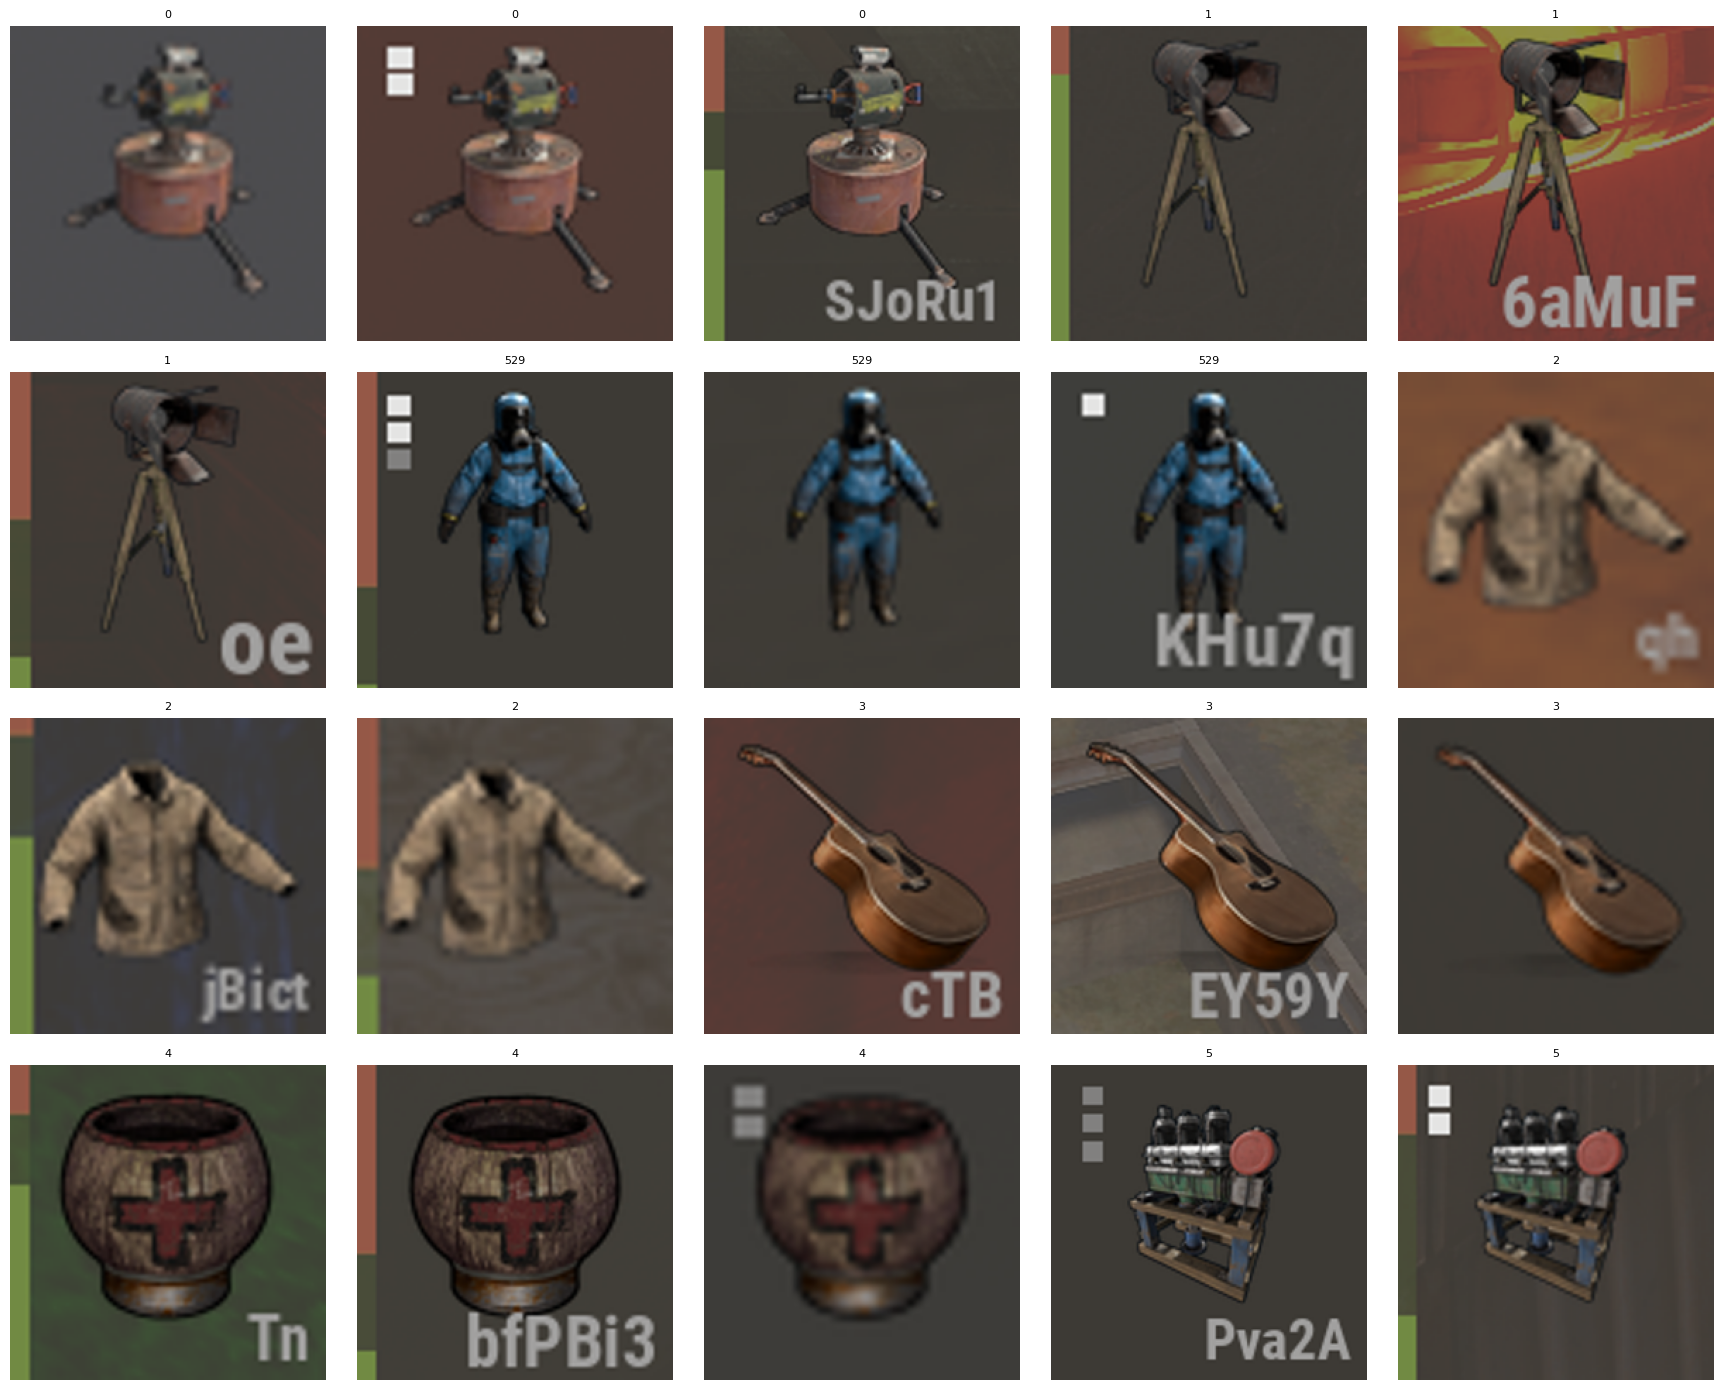

In [19]:
from torchvision.transforms.functional import to_pil_image

# --- пример аугментаций игровых иконок ---

imgs = []
labels = []

print("кол-во предметов * кол-во фонов * 3 =", len(items_info) * len(backgrounds_info) * 3)
print("картинок с применёнными агумнтеациям:", len(chest_item_dataset))

for i in range(0, len(backgrounds_info)*20, len(backgrounds_info)):
    imgs.append(to_pil_image(chest_item_dataset[i][0]))
    labels.append(chest_item_dataset[i][1])

show_grid(imgs, 5, 4, titles=labels)

# Классы детектирования

In [20]:
class CellsDetector:
    # Посчитанные параметры для определения коэффициентов сетки
    GRID_MODEL_ARGS = {
        'x0':      (0.15538758, 0.49977814),    # * width
        'delta_w': (0.04845760, -0.00002766),   # * width
        'cell_w':  (0.04531963, -0.00045448),   # * width
        'y0':      (-0.83747928, 0.99939329),   # * height
        'delta_h': (0.08609323, 0.00002244),    # * height
        'cell_h':  (0.08054795, -0.00079300),   # * height
    }

    # Предсказывает коэффициенты сетки по известному разрешению экрана и scale
    @staticmethod
    def predict_grid_params(width, height, scale):
        def v(param, dim):
            a, k = CellsDetector.GRID_MODEL_ARGS[param]
            return dim * (a * scale + k)
        return {
            'x0':      v('x0', width),
            'delta_w': v('delta_w', width),
            'cell_w':  v('cell_w', width),
            'y0':      v('y0', height),
            'delta_h': v('delta_h', height),
            'cell_h':  v('cell_h', height),
        }

    # Возращаем координаты всех ячеек сундука
    # Каждая ячейка: (tl_x, tl_y, br_x, br_y) tl — верхний левый угол, br — нижний правый.
    @staticmethod
    def all_slot_boxes(width, height, scale, n_cols, n_rows):
        p = CellsDetector.predict_grid_params(width, height, scale)
        x0, dw, cw = p['x0'], p['delta_w'], p['cell_w']
        y0, dh, ch = p['y0'], p['delta_h'], p['cell_h']
        boxes = []
        for row in range(n_rows):
            for col in range(n_cols):
                boxes.append((
                    round(x0 + col*dw),        # x1
                    round(y0 + row*dh),        # y1
                    round(x0 + col*dw + cw),   # x2
                    round(y0 + row*dh + ch),   # y2
                ))
        return boxes

    # Возращаем координаты [col][row] ячейки
    def slot_box(width, height, scale, col, row):
        p = CellsDetector.predict_grid_params(width, height, scale)
        x0, dw, cw = p['x0'], p['delta_w'], p['cell_w']
        y0, dh, ch = p['y0'], p['delta_h'], p['cell_h']
        return (
            round(x0 + col*dw),        # x1
            round(y0 + row*dh),        # y1
            round(x0 + col*dw + cw),   # x2
            round(y0 + row*dh + ch),   # y2
        )

    # Нарезает изображение сундука на ячейки по модели сетки
    @staticmethod
    def extract_cells(img: Image, scale, n_cols, n_rows, inset=3):
        """
        Возвращает список из n_cols*n_rows словарей:
        {'row', 'col', 'box' (рамка без отступа), 'image' (кроп PIL.Image)}
        """
        # 1) приводим вход к PIL.Image
        img = img.convert('RGB')
        W, H = img.size

        # 2) координаты всех ячеек по модели
        boxes = CellsDetector.all_slot_boxes(W, H, scale, n_cols, n_rows)

        # 3) режем
        cells = []
        for idx, (x1, y1, x2, y2) in enumerate(boxes):
            row, col = divmod(idx, n_cols)
            cx1 = max(0, min(W, x1 + inset)); cy1 = max(0, min(H, y1 + inset))
            cx2 = max(0, min(W, x2 - inset)); cy2 = max(0, min(H, y2 - inset))
            crop = img.crop((cx1, cy1, cx2, cy2))
            cells.append({'row': row, 'col': col, 'box': (x1, y1, x2, y2), 'image': crop})
        return cells

    # Нарезает изображение сундука на ячейки и берёт только одну
    @staticmethod
    def extract_cell(img: Image, scale, n_cols, n_rows, col, row, inset=3):
        """
        Возвращает словарь:
        {'row', 'col', 'box' (рамка без отступа), 'image' (кроп PIL.Image)}
        """
        img = img.convert('RGB')
        W, H = img.size

        # координаты всех ячеек по модели
        boxes = CellsDetector.all_slot_boxes(W, H, scale, n_cols, n_rows)

        # режем
        idx = row*n_cols + col
        x1, y1, x2, y2 = boxes[idx]
        row, col = divmod(idx, n_cols)
        cx1 = max(0, min(W, x1 + inset)); cy1 = max(0, min(H, y1 + inset))
        cx2 = max(0, min(W, x2 - inset)); cy2 = max(0, min(H, y2 - inset))
        crop = img.crop((cx1, cy1, cx2, cy2))
        return {'row': row, 'col': col, 'box': (x1, y1, x2, y2), 'image': crop}

In [21]:
class ChestValDataset(Dataset):
    def __init__(self, real_items, output_size=DATASET_OUTPUT_SIZE):
        self.real_items = real_items
        self.output_size = output_size

    def __len__(self):
        return len(self.real_items)

    def __getitem__(self, idx):
        resized_img = self.real_items[idx]["item_img"].resize(self.output_size)
        return to_tensor(resized_img), self.real_items[idx]["label"]

In [22]:
# Извлечь изображения всех предметов из скриншота сундука
# (внутри сундуков находяться все игровые предметы из файлов игры, кроме предметов из blacklist)
# (все предметы на страницах скриншотов уже отсортированы по возрастанию id-шника)
def get_all_items_from_chest(items_in_chest_info,
                             items_count,
                             n_cols=CHEST_N_COLS, # количество колонок в сундуке
                             n_rows=CHEST_N_ROWS): # количество рядов в сундуке
    res = []
    for info in items_in_chest_info:
        
        res_from_one_page = []
        for i in range(0, items_count):
            chest_page_idx = i // (n_cols * n_rows)
            item_in_page_idx = i % (n_cols * n_rows)
            
            # извлекаем изображнием из ячейки сундука
            item_img = CellsDetector.extract_cell(
                img=info['imgs'][chest_page_idx],
                scale=info['interface_scale'] / 100,
                n_cols=n_cols,
                n_rows=n_rows,
                col=item_in_page_idx % n_cols,
                row=item_in_page_idx // n_cols
            )["image"]
            
            res_from_one_page.append({
                "screen_width": info["screen_width"],
                "screen_height": info["screen_height"],
                "interface_scale": info["interface_scale"],
                "item_img": item_img,
            })
            
        apply_item_labels_list(res_from_one_page) # добавлям метки классов
        res += res_from_one_page
    return res

In [23]:
# --- извлечённые иконки реальных предметов ---

extracted_real_items = get_all_items_from_chest(items_in_chest_info, len(items_info))

In [24]:
import gc

# освобождаем память от ненужных изображений
for info in items_in_chest_info:
    for im in info["imgs"]:
        im.close()
    del info["imgs"]
    
gc.collect()

0

In [25]:
# --- объект Dataset ---

chest_val_dataset = ChestValDataset(
    real_items=extracted_real_items,
)

количество классов * 22 = 27258
кол-во скриншотов предметов: 27258


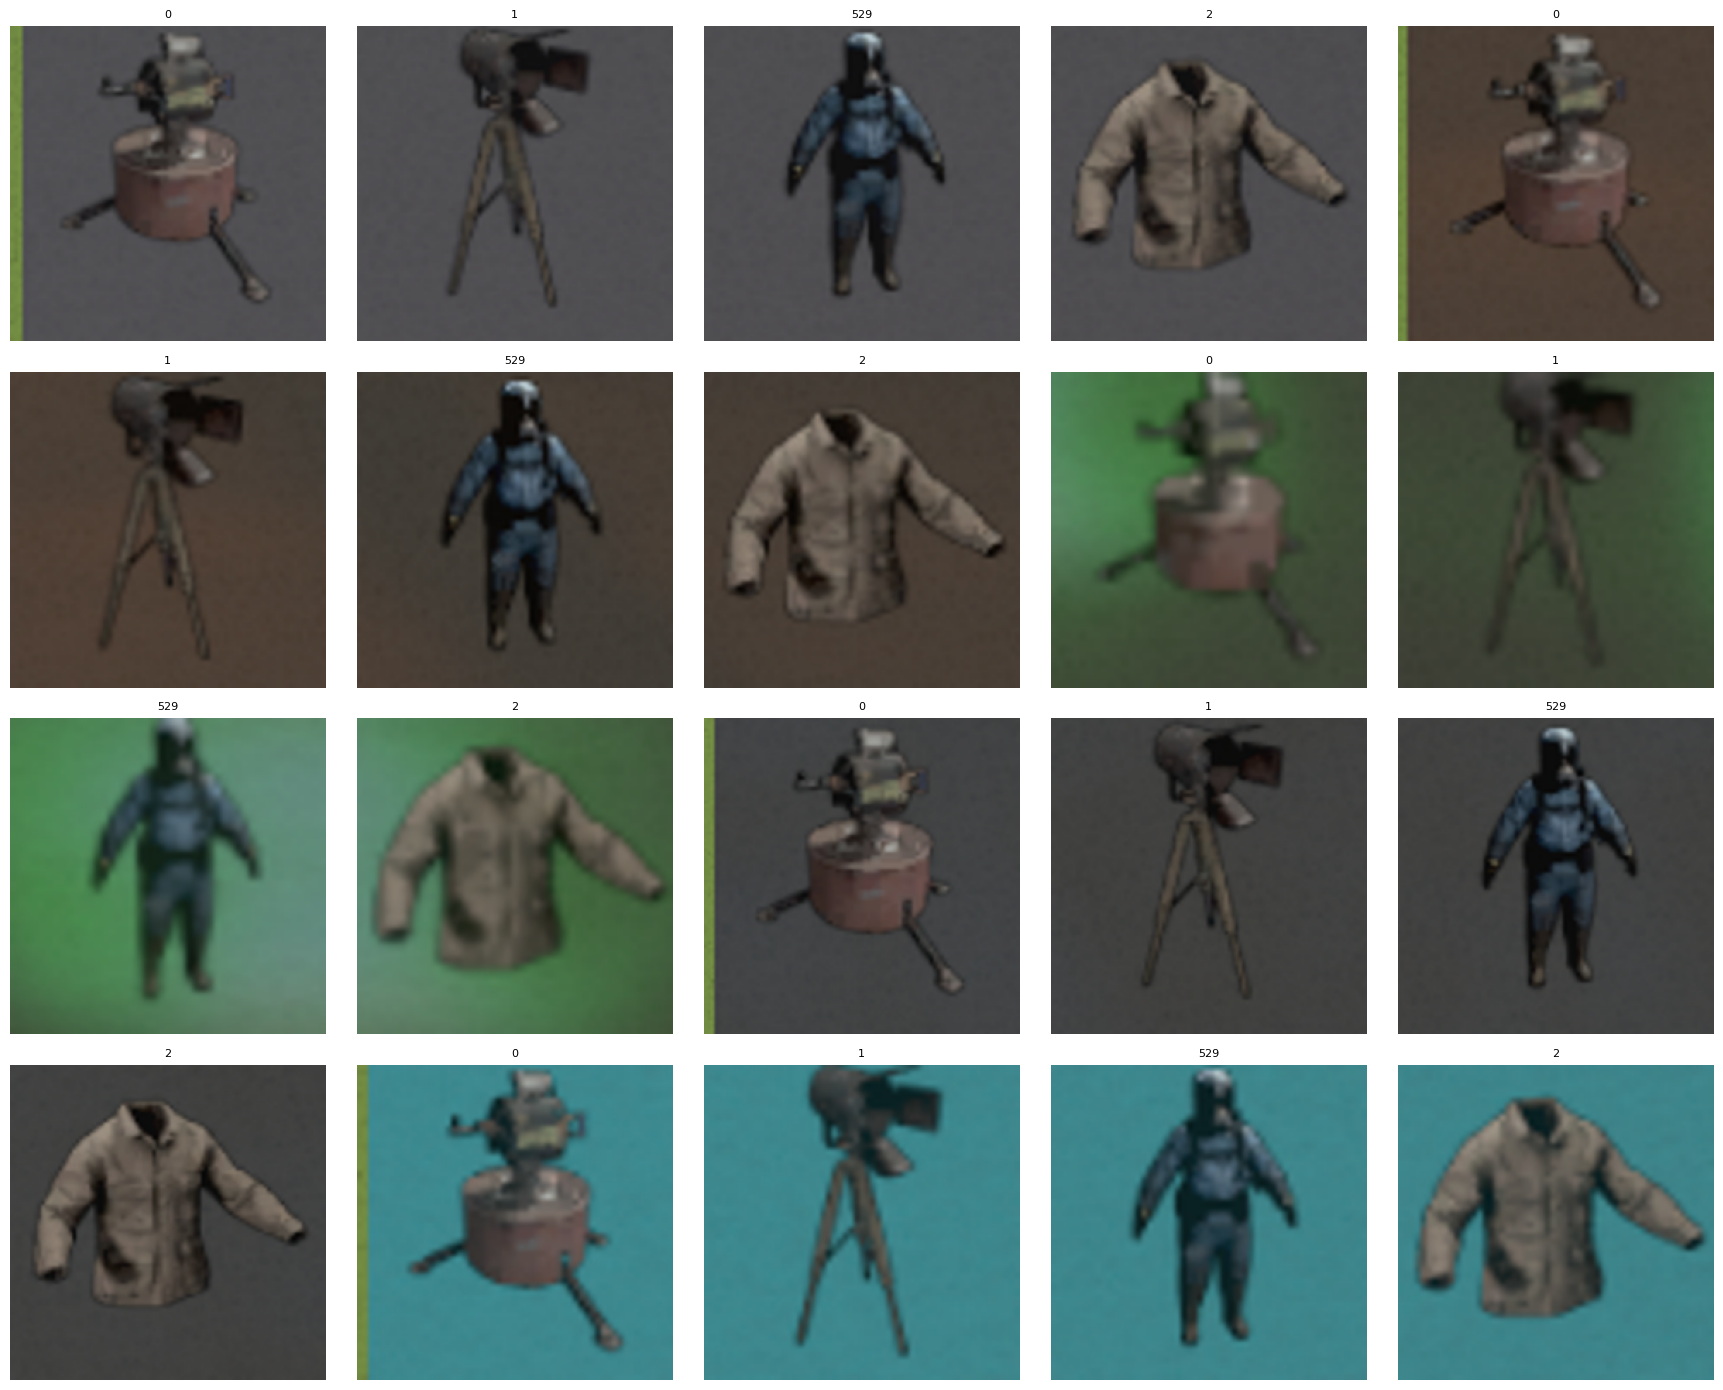

In [26]:
# --- пример детектирования предметов на рельных скриншотах ---

imgs = []
labels = []

print("количество классов * 22 =", len(items_info) * 22)
print("кол-во скриншотов предметов:", len(chest_val_dataset))

for i in range(0, len(items_info)*5, len(items_info)):
    for j in range(4):
        imgs.append(to_pil_image(chest_val_dataset[i+j][0]))
        labels.append(chest_val_dataset[i+j][1])

show_grid(imgs, 5, 4, titles=labels)

# Создание модели

В качестве основной модели была вабрана ConvNeXt-Tiny — она превращает изображение предмета в вектор-эмбеддинг. Классификация строится не напрямую, а через сравнение: для каждого класса (игрового предмета) задаётся эталонный эмбеддинг, и решение о принадлежности изображения к классу принимается по близости его вектора к эталонным. То есть модель определяет не «какой это предмет» напрямую, а «на какой эталон он больше всего похож» в векторном пространстве.

Чтобы дообучить ConvNeXt-Tiny под данную задачу, мы добавляем функцию потерь ArcFace. Она оценивает, насколько правильно модель разложила эмбеддинги (близко ли векторы одного предмета друг к другу и далеко ли от чужих), и на основе этой оценки корректирует веса ConvNeXt-Tiny в нужную сторону. ArcFace нужен только на этапе обучения.

После завершения обучения голова ArcFace отбрасывается. В работе используется только сам дообученный ConvNeXt-Tiny и получаемые с него векторы-эмбеддинги: изображение прогоняется через модель, а его класс определяется ближайшим эталонным эмбеддингом.

In [27]:
from sklearn.model_selection import train_test_split

# делим реальные данные на 2 выборки 50/50
real_items_val, real_items_test = train_test_split(
    extracted_real_items, test_size=0.5, random_state=42,
    stratify=[info["label"] for info in extracted_real_items]
)

In [28]:
val_labels = np.array([info["label"] for info in real_items_test])
test_labels = np.array([info["label"] for info in real_items_val])

print("Классов в val:", len(np.unique(val_labels)), "из", ITEMS_UNIQUE_CLASSES_COUNT)
print("Классов в test:", len(np.unique(test_labels)), "из", ITEMS_UNIQUE_CLASSES_COUNT)

print(f"Изображений в val: {len(val_labels)} из {len(extracted_real_items)}")
print(f"Изображений в test: {len(test_labels)} из {len(extracted_real_items)}")

Классов в val: 1211 из 1211
Классов в test: 1211 из 1211
Изображений в val: 13629 из 27258
Изображений в test: 13629 из 27258


In [29]:
train_ds = ChestItemDataset(
    items=[(item['img'], item['label']) for item in items_info],
    backgrounds_info=backgrounds_info,
)
valid_ds = ChestValDataset(real_items_val)
test_ds = ChestValDataset(real_items_test)

print("len(train_ds) =", len(train_ds))
print("len(valid_ds) =", len(valid_ds))
print("len(test_ds) =", len(test_ds))

len(train_ds) = 304794
len(valid_ds) = 13629
len(test_ds) = 13629


In [30]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          num_workers=12, persistent_workers=True, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

In [31]:
!pip install timm

In [32]:
import timm
import torch.nn as nn
import torch.nn.functional as F
import math


class ArcFaceHead(nn.Module):
    """ArcFace-голова: живёт только на обучении, на инференсе не нужна."""
    def __init__(self, embed_dim, num_classes, s=30.0, m=0.5):
        super().__init__()
        self.W = nn.Parameter(torch.empty(num_classes, embed_dim))
        nn.init.xavier_normal_(self.W)
        self.s = s
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)      # порог, за которым theta+m > 180°
        self.mm = math.sin(math.pi - m) * m  # линейный штраф за порогом

    def forward(self, embeddings, labels):
        x = F.normalize(embeddings)
        W = F.normalize(self.W)
        cos = (x @ W.t()).clamp(-1 + 1e-7, 1 - 1e-7)
        sin = torch.sqrt(1.0 - cos * cos)

        # cos(theta + m) = cos*cos_m - sin*sin_m
        cos_m = cos * self.cos_m - sin * self.sin_m
        # при theta+m > 180° формула теряет монотонность -> линейный штраф
        cos_m = torch.where(cos > self.th, cos_m, cos - self.mm)

        target = F.one_hot(labels, cos.size(1)).bool()
        logits = torch.where(target, cos_m, cos) * self.s
        return logits


class ConvNeXtTinyModel(nn.Module):
    def __init__(self, num_classes, embed_dim=256, s=30.0, m=0.5):
        super().__init__()
        self.backbone = timm.create_model('convnext_tiny', pretrained=True, num_classes=0) # модель ConvNeXt-Tiny (backbone)
        self.proj = nn.Linear(self.backbone.num_features, embed_dim)     # дополнительный слой (768 -> 256)
        self.arcface = ArcFaceHead(embed_dim, num_classes, s=s, m=m)     # ArcFace голова 

    # замораживаем только backbone
    def freeze_backbone(self, unfreeze_last_stage=False):
        for p in self.backbone.parameters():
            p.requires_grad = False
        if unfreeze_last_stage:
            for p in self.backbone.stages[3].parameters():
                p.requires_grad = True

    def unfreeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def embed(self, x):
        """Инференс: картинка -> нормализованный эмбеддинг (для центроидов)."""
        return F.normalize(self.proj(self.backbone(x)))

    def forward(self, x, labels):
        """Обучение: логиты ArcFace."""
        return self.arcface(self.proj(self.backbone(x)), labels)

/home/user/jupyter_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Оптимизаторы и Лосс-функции

Составим несколько конфигураций, чтобы на малом прогоне определить наиболее подходящие параметры для данной задачи

In [33]:
# ============================================================================
# CONFIG_A — BASELINE. Точка отсчёта, все остальные конфиги наследуются от него.
# Классические параметры ArcFace (s=30, m=0.5) + AdamW с осторожным LR backbone.
# ============================================================================
CONFIG_A = {
    'name': 'baseline',
    'loss': 'arcface',
    's': 30.0,                  # scale: во сколько раз "растягиваются" косинусные логиты
    'm': 0.5,                   # margin: угловой зазор между классами
    'optimizer': 'adamw',
    'lr_backbone': 1e-5,        # низкий LR: backbone предобучен, его подстраиваем, а не переучиваем
    'lr_head': 1e-4,            # LR головы на фазе 2 (backbone разморожен)
    'lr_head_phase1': 1e-3,     # LR головы на фазе 1 (backbone заморожен) — можно выше
    'weight_decay': 1e-4,
    'freeze_epochs': 3,         # сколько эпох держать backbone замороженным
}

# ============================================================================
# CONFIG_B — МЯГКИЙ MARGIN. Отличие от A: только m (0.5 -> 0.3).
# Гипотеза: при 1238 классах жёсткий margin 0.5 усложняет задачу и мешает
# сходимости. Мягкий margin учится стабильнее, хотя классы раздвигает слабее.
# ============================================================================
CONFIG_B = {**CONFIG_A, 'name': 'soft_margin', 'm': 0.3}

# ============================================================================
# CONFIG_C — ВЫСОКИЙ SCALE. Отличие от A: s (30 -> 64) И m (0.5 -> 0.3).
# Связка из оригинальной статьи ArcFace. Больший scale делает логиты "острее",
# градиент сильнее. ВНИМАНИЕ: меняются два параметра сразу — если C выиграет,
# прогони отдельно {**CONFIG_A, 's': 64.0}, чтобы понять, что именно сработало.
# ============================================================================
CONFIG_C = {**CONFIG_A, 'name': 'high_scale', 's': 64.0, 'm': 0.3}

# ============================================================================
# CONFIG_D — АГРЕССИВНЕЕ ДООБУЧАЕМ BACKBONE. Отличие от A: только lr_backbone (1e-5 -> 5e-5).
# Гипотеза: данных много (генерация на лету, ~300k примеров), переобучение
# почти не грозит, поэтому backbone можно адаптировать под игровые иконки смелее.
# ============================================================================
CONFIG_D = {**CONFIG_A, 'name': 'higher_lr', 'lr_backbone': 5e-5}

# ============================================================================
# CONFIG_E — SGD ВМЕСТО ADAMW. Отличие от A: оптимизатор (+ его LR и weight_decay).
# Все LR на 2 порядка выше — SGD не адаптирует шаг по параметрам, с LR уровня
# AdamW он просто не сдвинется. Ожидаемо отстанет на коротких прогонах
# (медленно разгоняется), но может выиграть на длинной дистанции.
# ============================================================================
CONFIG_E = {**CONFIG_A,
    'name': 'sgd',
    'optimizer': 'sgd',
    'lr_backbone': 1e-3,        # x100 относительно AdamW
    'lr_head': 1e-2,
    'lr_head_phase1': 1e-1,
    'momentum': 0.9,
    'nesterov': True,
    'weight_decay': 5e-4,       # у SGD принято выше, чем у AdamW
}

configs = [CONFIG_A, CONFIG_B, CONFIG_C, CONFIG_D, CONFIG_E]

# Обучение 

Модель состоит из трёх частей:

1) ConvNeXt-Tiny (backbone) — превращает изображение в вектор признаков (768 значений);
2) линейный слой — сжимает признаки до компактного эмбеддинга (768 → 256);
3) ArcFace-голова — нужна только при обучении, оценивает правильность эмбеддингов.

ConvNeXt-Tiny приходит предобученным, а линейный слой и ArcFace-голова инициализированы случайно. На старте они выдают хаотичные градиенты, которые могут повредить качественные признаки backbone. Поэтому обучение идёт в два этапа:

Этап 1. Backbone заморожен — обучаются только линейный слой и ArcFace-голова. Они подстраиваются под стабильные признаки, лосс падает до разумного уровня, градиенты успокаиваются.

Этап 2. Backbone размораживается и дообучается вместе с остальными частями, но с пониженным learning rate: его веса уже хорошие, их нужно слегка адаптировать под игровые иконки, а не переучивать заново.

**Метрики оценки**

Для сравнения конфигураций используем top-1 accuracy и top-5 accuracy.

Top-1 accuracy — основная метрика: доля предметов, распознанных верно (ближайший центроид оказался правильным классом). Классы в валидационной выборке сбалансированы — ровно 11 примеров на каждый из 1238 предметов, — поэтому accuracy не искажается перекосом, а precision/recall/F1 дали бы практически те же значения и лишь усложнили сравнение.

Top-5 accuracy — вспомогательная, показывает, попал ли правильный класс в пятёрку ближайших центроидов. Она нужна для диагностики характера ошибок: если top-1 заметно ниже top-5, модель ошибается «мягко» — путает визуально похожие предметы, и проблема в тонкой разделимости эмбеддингов. Если же обе метрики близки, ошибки грубые, и качество векторного пространства низкое в принципе. Это разные проблемы, требующие разных решений.

In [34]:
!pip install lightning

In [35]:
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy


class LitArcFaceModel(L.LightningModule):
    def __init__(self, model, num_classes, cfg):
        """
        model : ConvNeXtTinyModel (backbone + proj + arcface)
        cfg   : конфиг с ключами lr_backbone, lr_head, lr_head_phase1,
                optimizer, weight_decay, freeze_epochs
        """
        super().__init__()
        self.model = model
        self.num_classes = num_classes
        self.cfg = cfg
        self.loss_func = nn.CrossEntropyLoss()

        self.metrics = nn.ModuleDict()
        self.metrics['train_loss'] = MeanMetric()
        self.metrics['train_acc']  = MulticlassAccuracy(num_classes=num_classes, average='micro')
        self.metrics['valid_top1'] = MulticlassAccuracy(num_classes=num_classes, average='micro')
        self.metrics['valid_top5'] = MulticlassAccuracy(num_classes=num_classes, average='micro', top_k=5)

        self._val_embeddings = []
        self._val_labels = []

    def forward(self, x):
        return self.model.embed(x)

    # ---------- ЗАМОРОЗКА: две фазы, автоматически по эпохам ----------
    def on_train_epoch_start(self):
        freeze_epochs = self.cfg.get('freeze_epochs', 3)

        if self.current_epoch == 0:
            # ФАЗА 1: backbone заморожен целиком, учатся только proj + arcface
            self.model.freeze_backbone(unfreeze_last_stage=False)
            self._set_lr(backbone=0.0,
                         head=self.cfg.get('lr_head_phase1', 1e-3))
            print(f"[epoch 0] ФАЗА 1: backbone заморожен")

        elif self.current_epoch == freeze_epochs:
            # ФАЗА 2: размораживаем последнюю стадию, снижаем LR головы
            self.model.freeze_backbone(unfreeze_last_stage=True)
            self._set_lr(backbone=self.cfg['lr_backbone'],
                         head=self.cfg['lr_head'])
            print(f"[epoch {freeze_epochs}] ФАЗА 2: разморожена stages[3]")

    def _set_lr(self, backbone, head):
        """Меняет LR в группах оптимизатора (порядок как в configure_optimizers)."""
        opt = self.optimizers()
        opt = opt.optimizer if hasattr(opt, 'optimizer') else opt
        opt.param_groups[0]['lr'] = backbone   # backbone
        opt.param_groups[1]['lr'] = head       # proj
        opt.param_groups[2]['lr'] = head       # arcface

    # ---------- TRAIN: через ArcFace-голову ----------
    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self.model(imgs, labels)
        loss = self.loss_func(logits, labels)

        self.metrics['train_loss'].update(loss.detach())
        self.metrics['train_acc'].update(logits.detach(), labels)
        self.log('train_loss', self.metrics['train_loss'], on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc',  self.metrics['train_acc'],  on_step=False, on_epoch=True, prog_bar=True)
        return loss

    # ---------- VALID: через центроиды, без головы ----------
    def on_validation_epoch_start(self):
        self._val_embeddings.clear()
        self._val_labels.clear()

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        emb = self.model.embed(imgs)
        self._val_embeddings.append(emb.detach())
        self._val_labels.append(labels)

    def on_validation_epoch_end(self):
        embs = torch.cat(self._val_embeddings)
        labels = torch.cat(self._val_labels)

        centroids = torch.zeros(self.num_classes, embs.size(1), device=embs.device)
        for c in labels.unique():
            centroids[c] = embs[labels == c].mean(0)
        centroids = F.normalize(centroids)

        sims = embs @ centroids.t()
        self.metrics['valid_top1'].update(sims, labels)
        self.metrics['valid_top5'].update(sims, labels)
        self.log('valid_top1', self.metrics['valid_top1'], prog_bar=True)
        self.log('valid_top5', self.metrics['valid_top5'], prog_bar=True)

        own = sims.gather(1, labels.unsqueeze(1)).mean()
        self.log('valid_separation', own - sims.mean())

    # ---------- оптимизатор ----------
    def configure_optimizers(self):
        groups = [
            {'params': self.model.backbone.parameters(), 'lr': self.cfg['lr_backbone']},
            {'params': self.model.proj.parameters(),     'lr': self.cfg['lr_head']},
            {'params': self.model.arcface.parameters(),  'lr': self.cfg['lr_head']},
        ]
        if self.cfg['optimizer'] == 'sgd':
            return torch.optim.SGD(groups,
                                   momentum=self.cfg.get('momentum', 0.9),
                                   nesterov=self.cfg.get('nesterov', True),
                                   weight_decay=self.cfg['weight_decay'])
        return torch.optim.AdamW(groups, weight_decay=self.cfg['weight_decay'])

In [36]:
import time
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger


def lightning_train_pipeline(config, train_loader, valid_loader, num_classes, main_metric_name='valid_top1', epochs=15):
    name = config['name']
    print(f"Конфигурация {name}:")
    print("-------------------")
    start_time = time.perf_counter()

    tb_logger = TensorBoardLogger(save_dir="lightning_logs", name=name)

    ckpt_cb = ModelCheckpoint(monitor=main_metric_name, mode="max", save_top_k=1, save_last=True, filename=f"best_model_{name}")
    early_cb = EarlyStopping(monitor=main_metric_name, mode="max", patience=6)

    # создаём модель с параметрами
    backbone_model = ConvNeXtTinyModel(num_classes=num_classes, embed_dim=256, s=config['s'], m=config['m'])
    lit_model = LitArcFaceModel(backbone_model, num_classes=num_classes, cfg=config)

    trainer = L.Trainer(max_epochs=epochs, accelerator="gpu", devices=1, precision="16-mixed", callbacks=[ckpt_cb, early_cb], enable_model_summary=False, enable_progress_bar=True, logger=tb_logger)
    trainer.fit(model=lit_model, train_dataloaders=train_loader, val_dataloaders=valid_loader)

    best_metrics = trainer.validate(ckpt_path="best", dataloaders=valid_loader, verbose=False)[0]

    elapsed = time.perf_counter() - start_time
    print(f"Время обучения: {elapsed:.1f} сек")
    print("Метрики лучшей модели (valid):", best_metrics)
    print()

    return {'name': name, 'metrics': best_metrics,
            'time': elapsed, 'ckpt': ckpt_cb.best_model_path}

In [37]:
# Запускаем тестовое обучение на разных конфигах (20 эпох для определения наилучших параметров)

results = []

for conf in configs:
    res = lightning_train_pipeline(
        conf, 
        train_loader, 
        valid_loader, 
        ITEMS_UNIQUE_CLASSES_COUNT, 
        main_metric_name='valid_top1', 
        epochs=20
    )
    results.append(res)

Конфигурация baseline:
-------------------


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 0: 100%|█████████████████████| 1191/1191 [03:22<00:00,  5.89it/s, v_num=3]
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation: |                                             | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████████████| 54/54 [00:09<00:00,  5.62it/s]
Epoch 1: 100%|█| 1191/1191 [03:19<00:00,  5.97it/s, v_num=3, valid_top1=0.      
Validation: |                                       | 0/? [00:00<?, ?it/s]
Validation: |                                       | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|████████████| 54/54 [00:07<00:00,  7.35it/s]
Epoch 2: 100%|█| 1191/1191 [03:19<00:00,  5.98it/s, v_num=3, valid_top1=0.
Validation: |                                       | 0/? [00:00<?, ?it/s]
Validation: |                                       | 0/? [00:00<?, ?it/s]
Epoch 3:   0%| | 0/1191 [00:00<?, ?it/s, v_num=3, valid_top1=0.996, valid_[epoch 3] ФАЗА 2: разморожена stages[3]
Epoch 3: 100%|█| 1191/1191 [03:

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|█| 1191/1191 [03:38<00:00,  5.45it/s, v_num=3, valid_top1=0


...

Validation DataLoader 0: 100%|████████████| 54/54 [00:07<00:00,  7.04it/s]
Время обучения: 2651.9 сек
Метрики лучшей модели (valid): {'valid_top1': 0.9985325336456299, 'valid_top5': 0.999853253364563, 'valid_separation': 0.9164941310882568}

Конфигурация sgd:
-------------------


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 0: 100%|███████████████| 1191/1191 [03:28<00:00,  5.71it/s, v_num=2]
Validation: |                                       | 0/? [00:00<?, ?it/s]
Validation: |                                       | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|████████████| 54/54 [00:07<00:00,  7.37it/s]
Epoch 1: 100%|█| 1191/1191 [03:26<00:00,  5.76it/s, v_num=2, valid_top1=0.
Validation: |                                       | 0/? [00:00<?, ?it/s]
Validation: |                                       | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|████████████| 54/54 [00:07<00:00,  7.37it/s]
Epoch 2: 100%|█| 1191/1191 [03:26<00:00,  5.77it/s, v_num=2, valid_top1=0.
Validation: |                                       | 0/? [00:00<?, ?it/s]
Validation: |                                       | 0/? [00:00<?, ?it/s]
Epoch 3:   0%| | 0/1191 [00:00<?, ?it/s, v_num=2, valid_top1=0.996, valid_[epoch 3] ФАЗА 2: разморожена stages[3]
Epoch 3: 100%|█| 1191/1191 [03:32<00:00,  5.60it/s, v_num=2, 

Restoring states from the checkpoint path at lightning_logs/sgd/version_2/checkpoints/best_model_sgd.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at lightning_logs/sgd/version_2/checkpoints/best_model_sgd.ckpt


Validation DataLoader 0: 100%|████████████| 54/54 [00:07<00:00,  7.04it/s]
Время обучения: 1986.9 сек
Метрики лучшей модели (valid): {'valid_top1': 0.9963313341140747, 'valid_top5': 0.9997798800468445, 'valid_separation': 0.8474758267402649}



# Результаты

In [38]:
for res in results:
    print(res)

{'name': 'baseline', 'metrics': {'valid_top1': 0.9991928935050964, 'valid_top5': 1.0, 'valid_separation': 0.916172206401825}, 'time': 4359.09113339, 'ckpt': 'lightning_logs/baseline/version_3/checkpoints/best_model_baseline.ckpt'}
{'name': 'soft_margin', 'metrics': {'valid_top1': 0.9991928935050964, 'valid_top5': 0.9999266266822815, 'valid_separation': 0.888535737991333}, 'time': 4436.800650183, 'ckpt': 'lightning_logs/soft_margin/version_2/checkpoints/best_model_soft_margin.ckpt'}
{'name': 'high_scale', 'metrics': {'valid_top1': 0.9991195201873779, 'valid_top5': 1.0, 'valid_separation': 0.8734028935432434}, 'time': 4462.544584060999, 'ckpt': 'lightning_logs/high_scale/version_2/checkpoints/best_model_high_scale.ckpt'}
{'name': 'higher_lr', 'metrics': {'valid_top1': 0.9985325336456299, 'valid_top5': 0.999853253364563, 'valid_separation': 0.9164941310882568}, 'time': 2651.9243947649993, 'ckpt': 'lightning_logs/higher_lr/version_2/checkpoints/best_model_higher_lr.ckpt'}
{'name': 'sgd', '

In [66]:
# colab magic command
%load_ext tensorboard
# dir with logs
%tensorboard --logdir lightning_logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 46445), started 7:10:23 ago. (Use '!kill 46445' to kill it.)

Анализируя модели по основной метрике (top-1 accuracy), можно заметить, что все конфигурации показали практически одинаковый результат — разброс между лучшими (baseline и soft_margin, 0.99919) и high_scale (0.99912) составляет менее 0.01%, то есть около одной картинки из 13629. При таком разбросе выбор по top-1 статистически необоснован: разница лежит в пределах шума и могла бы измениться от одного лишь random seed.

В качестве дополнительного критерия используется separation — разница между близостью эмбеддинга к своему центроиду и к чужим. Эта метрика показывает, насколько надёжно разделено векторное пространство, и напрямую влияет на две практические задачи: возможность построить порог отказа (для пустых слотов и незнакомых предметов) и корректность добавления новых предметов через центроиды без переобучения.

Конфигурация baseline оказалась лучшей или разделила первое место сразу по всем трём метрикам: top-1 = 0.99919 (лучший результат), top-5 = 1.0 (правильный класс всегда попадает в пятёрку ближайших) и separation = 0.916 (наравне с higher_lr, 0.9165, — разница неразличима). Дополнительный аргумент в её пользу — это самая простая и стандартная конфигурация (s=30, m=0.5, AdamW, консервативный lr_backbone=1e-5): при равном результате нет причин усложнять. Модель baseline выбрана как наиболее подходящая.

Слабейшей оказалась SGD-конфигурация: и по top-1 (0.99633), и по separation (0.847) она уступает всем остальным.

**Характеристики baseline модели:**

valid_top1. Метрика уверенно растёт от 0.9965 до максимума ~0.9991 на шаге ~19000, после чего выходит на плато с небольшими колебаниями в пределах 0.03%. Модель полностью стабилизировалась.
train_loss. Монотонно падает на всём протяжении (1.2 → 0.003), выходя практически на ноль к концу обучения. Модель полностью освоила обучающую выборку.
valid_separation. Растёт дольше остальных метрик — до конца обучения (0.84 → 0.916), продолжая улучшаться даже когда точность уже вышла на плато. Векторное пространство продолжало уплотняться после того, как классификация перестала улучшаться.

**Вывод:**

Train_loss, упавший практически до нуля при остановившемся valid_top1, означает, что модель полностью выучила обучающие данные, а на валидации улучшений больше нет. Запас исчерпан. EarlyStopping сработал корректно: сохранил чекпоинт на пике и остановил обучение, когда стало ясно, что дальше улучшений не будет.

Увеличивать количество эпох не нужно — кривые показывают не оборванный рост, а достигнутый максимум с последующим плато. Больший patience лишь продлит обучение без выигрыша. Модель считается обученной: 99.92% top-1, 100% top-5.

# Проверка на тестовой выборке

In [40]:
import lightning as L

# Прогоняет сохранённую модель по тестовой выборке.
def evaluate_on_test(lit_model, test_loader):
    
    # Trainer только для оценки (без логгера и обучения)
    accelerator = "gpu" if torch.cuda.is_available() else "cpu"
    trainer = L.Trainer(accelerator=accelerator, devices=1,
                        precision="16-mixed" if accelerator == "gpu" else "32-true",
                        logger=False, enable_model_summary=False)

    # прогон валидации на тестовой выборке
    metrics = trainer.validate(lit_model, dataloaders=test_loader, verbose=False)[0]
    return metrics

In [42]:
best_model_ckpt = 'lightning_logs/baseline/version_0/checkpoints/best_model_baseline.ckpt'
best_model_config = CONFIG_A

# пересоздаём архитектуру с параметрами из конфига
backbone_model = ConvNeXtTinyModel(num_classes=ITEMS_UNIQUE_CLASSES_COUNT, embed_dim=256,
                                   s=best_model_config['s'], m=best_model_config['m'])

# подгружаем веса из чекпоинта
lit_model = LitArcFaceModel.load_from_checkpoint(
    best_model_ckpt,
    model=backbone_model,
    num_classes=ITEMS_UNIQUE_CLASSES_COUNT,
    cfg=best_model_config,
)

In [43]:
# метрики модели на тестовой выборке
test_metrics = evaluate_on_test(lit_model, test_loader)
test_metrics

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation DataLoader 0: 100%|██████████████| 54/54 [00:08<00:00,  6.66it/s]


{'valid_top1': 0.9983124136924744,
 'valid_top5': 0.999853253364563,
 'valid_separation': 0.9154551029205322}

# Анализ ошибок модели

In [44]:
import torch
import torch.nn.functional as F
from collections import Counter

# Прогоняет все картинки через модель и собирает их эмбеддинги.
def compute_embeddings(model, loader, device=None):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.eval().to(device)

    all_embs, all_labels = [], []
    with torch.no_grad():                      # градиенты не нужны — только инференс
        for imgs, labels in loader:
            emb = model.embed(imgs.to(device))  # картинка -> вектор
            all_embs.append(emb.cpu())
            all_labels.append(labels)
    return torch.cat(all_embs), torch.cat(all_labels) # возвращает (embs, labels)

# Строит эталонный вектор (центроид) для каждого класса (среднее всех эмбеддингов данного класса)
def build_centroids(embs, labels, num_classes):
    centroids = torch.zeros(num_classes, embs.size(1))
    for c in labels.unique():
        centroids[c] = embs[labels == c].mean(0)
    return F.normalize(centroids)               # нормируем для косинусной близости

# Классифицирует эмбеддинги по ближайшему центроиду.
def predict_by_centroids(embs, centroids):
    sims = embs @ centroids.t()      # косинусная близость к каждому классу
    return sims.argmax(1), sims.max(1).values # возвращает (предсказанный класс, уверенность) 

In [45]:
# Ошибки на тестовых данных
embs, labels = compute_embeddings(lit_model.model, test_loader)
centroids = build_centroids(embs, labels, ITEMS_UNIQUE_CLASSES_COUNT)
preds, confidence = predict_by_centroids(embs, centroids)

wrong_idx = (preds != labels).nonzero(as_tuple=True)[0]
print(f"Ошибок: {len(wrong_idx)} из {len(labels)} ({len(wrong_idx)/len(labels)*100:.2f}%)")

Ошибок: 23 из 13629 (0.17%)


In [46]:
pairs = Counter((int(labels[i]), int(preds[i])) for i in wrong_idx)
print("\nСамые частые ошибки:")
for (true_c, pred_c), cnt in pairs.most_common(25):
    print(f"{true_c} -> {pred_c}\t{cnt} раз")


Самые частые ошибки:
803 -> 958	3 раз
661 -> 72	2 раз
203 -> 335	2 раз
695 -> 626	2 раз
332 -> 645	1 раз
464 -> 582	1 раз
76 -> 1168	1 раз
609 -> 157	1 раз
89 -> 974	1 раз
4 -> 348	1 раз
529 -> 51	1 раз
335 -> 203	1 раз
179 -> 248	1 раз
943 -> 8	1 раз
266 -> 380	1 раз
932 -> 1210	1 раз
966 -> 852	1 раз
8 -> 943	1 раз


Все ошибки модели:
cлева - входное изображение и его реальный класс
справа - предмет, который модель увидела на картинке (предсказала неверно)


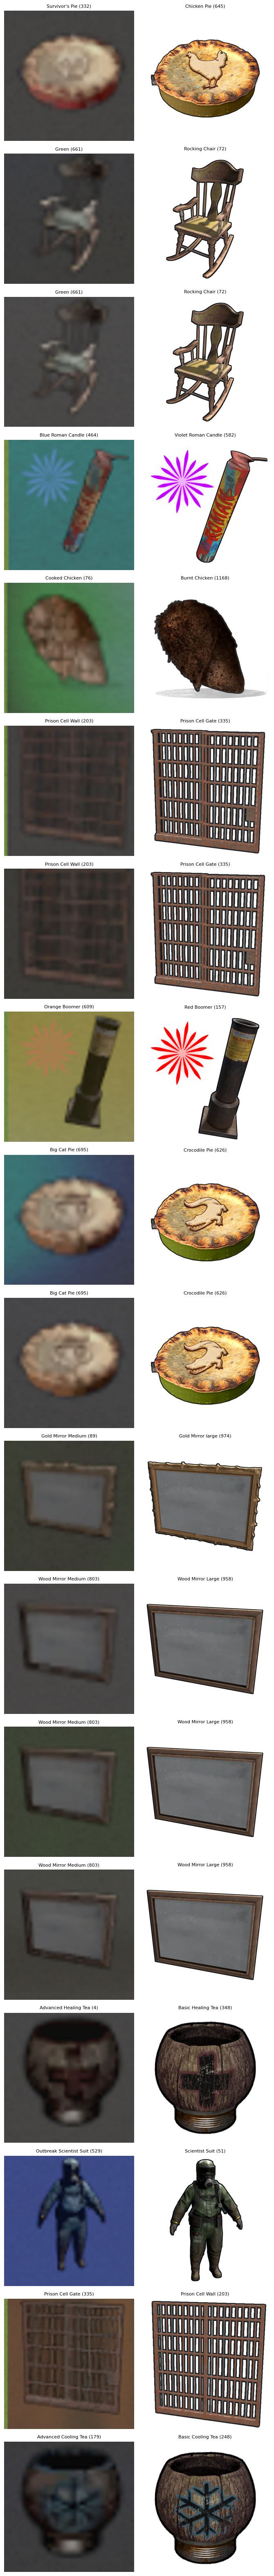

In [47]:
# Индексы примеров, где истинный класс = true_c, а модель предсказала pred_c.
def find_pair_indices(true_c, pred_c):
    return [i for i in range(len(labels))
            if int(labels[i]) == true_c and int(preds[i]) == pred_c]

# Найти предметы по label
def find_item_info(label):
    return [info for info in items_info if (info["label"] == label)]
            
imgs = []
lbls = []

print("Все ошибки модели:")
print("cлева - входное изображение и его реальный класс")
print("справа - предмет, который модель увидела на картинке (предсказала неверно)")

for true_c, pred_c in pairs:
    for ind in find_pair_indices(int(true_c), int(pred_c)):
        true_item_info = find_item_info(true_c)[0]
        pred_item_info = find_item_info(pred_c)[0]
        
        imgs += [
            to_pil_image(test_ds[ind][0]),  # изображение, которые было неверно предсказано
            pred_item_info["img"],  # иконка предмета, которую модель посчитала похожей
        ]
        lbls += [
            f"{true_item_info["Name"]} ({true_item_info["label"]})",
            f"{pred_item_info["Name"]} ({pred_item_info["label"]})"
        ]

show_grid(imgs, 2, len(pairs), titles=lbls)

Анализ ошибок показывает, что модель путается преимущественно на визуально похожих предметах и на изображениях низкого качества (при малом scale иконка в игре сжимается до 40–50 пикселей).

# Определение threshold

Для более надёжной работы модели введём порог уверенности. Он нужен не только для отсева ошибок между известными классами, но и для случаев, когда на вход попадает то, чего модель никогда не видела: предметы, добавленные в игру после обучения, частично перекрытые иконки или посторонние элементы интерфейса. Без порога модель в таких ситуациях всё равно выдаст ближайший по вектору класс.

In [48]:
correct = preds == labels                    # булева маска: True = верно распознано
conf_ok  = confidence[correct]               # уверенность на верных ответах
conf_bad = confidence[~correct]              # уверенность на ошибках

print(f"Верных: {correct.sum()}, ошибок: {(~correct).sum()}")
print(f"\nУверенность ВЕРНЫХ:    среднее {conf_ok.mean():.3f}, "
      f"min {conf_ok.min():.3f}, 1-й перцентиль {conf_ok.quantile(0.01):.3f}")
print(f"Уверенность ОШИБОЧНЫХ: среднее {conf_bad.mean():.3f}, "
      f"max {conf_bad.max():.3f}, медиана {conf_bad.median():.3f}")

Верных: 13606, ошибок: 23

Уверенность ВЕРНЫХ:    среднее 0.936, min 0.457, 1-й перцентиль 0.679
Уверенность ОШИБОЧНЫХ: среднее 0.702, max 0.899, медиана 0.671


In [49]:
# Фейковые изображения предметов

fake_item_dataset = ChestItemDataset(
    items=[(img, -1) for img in fake_items_imgs],
    backgrounds_info=backgrounds_info,
    backgrounds_per_item=1,
    overlays_per_background=1,
)

fake_item_dataset_len = len(fake_item_dataset)
print(fake_item_dataset_len)

100


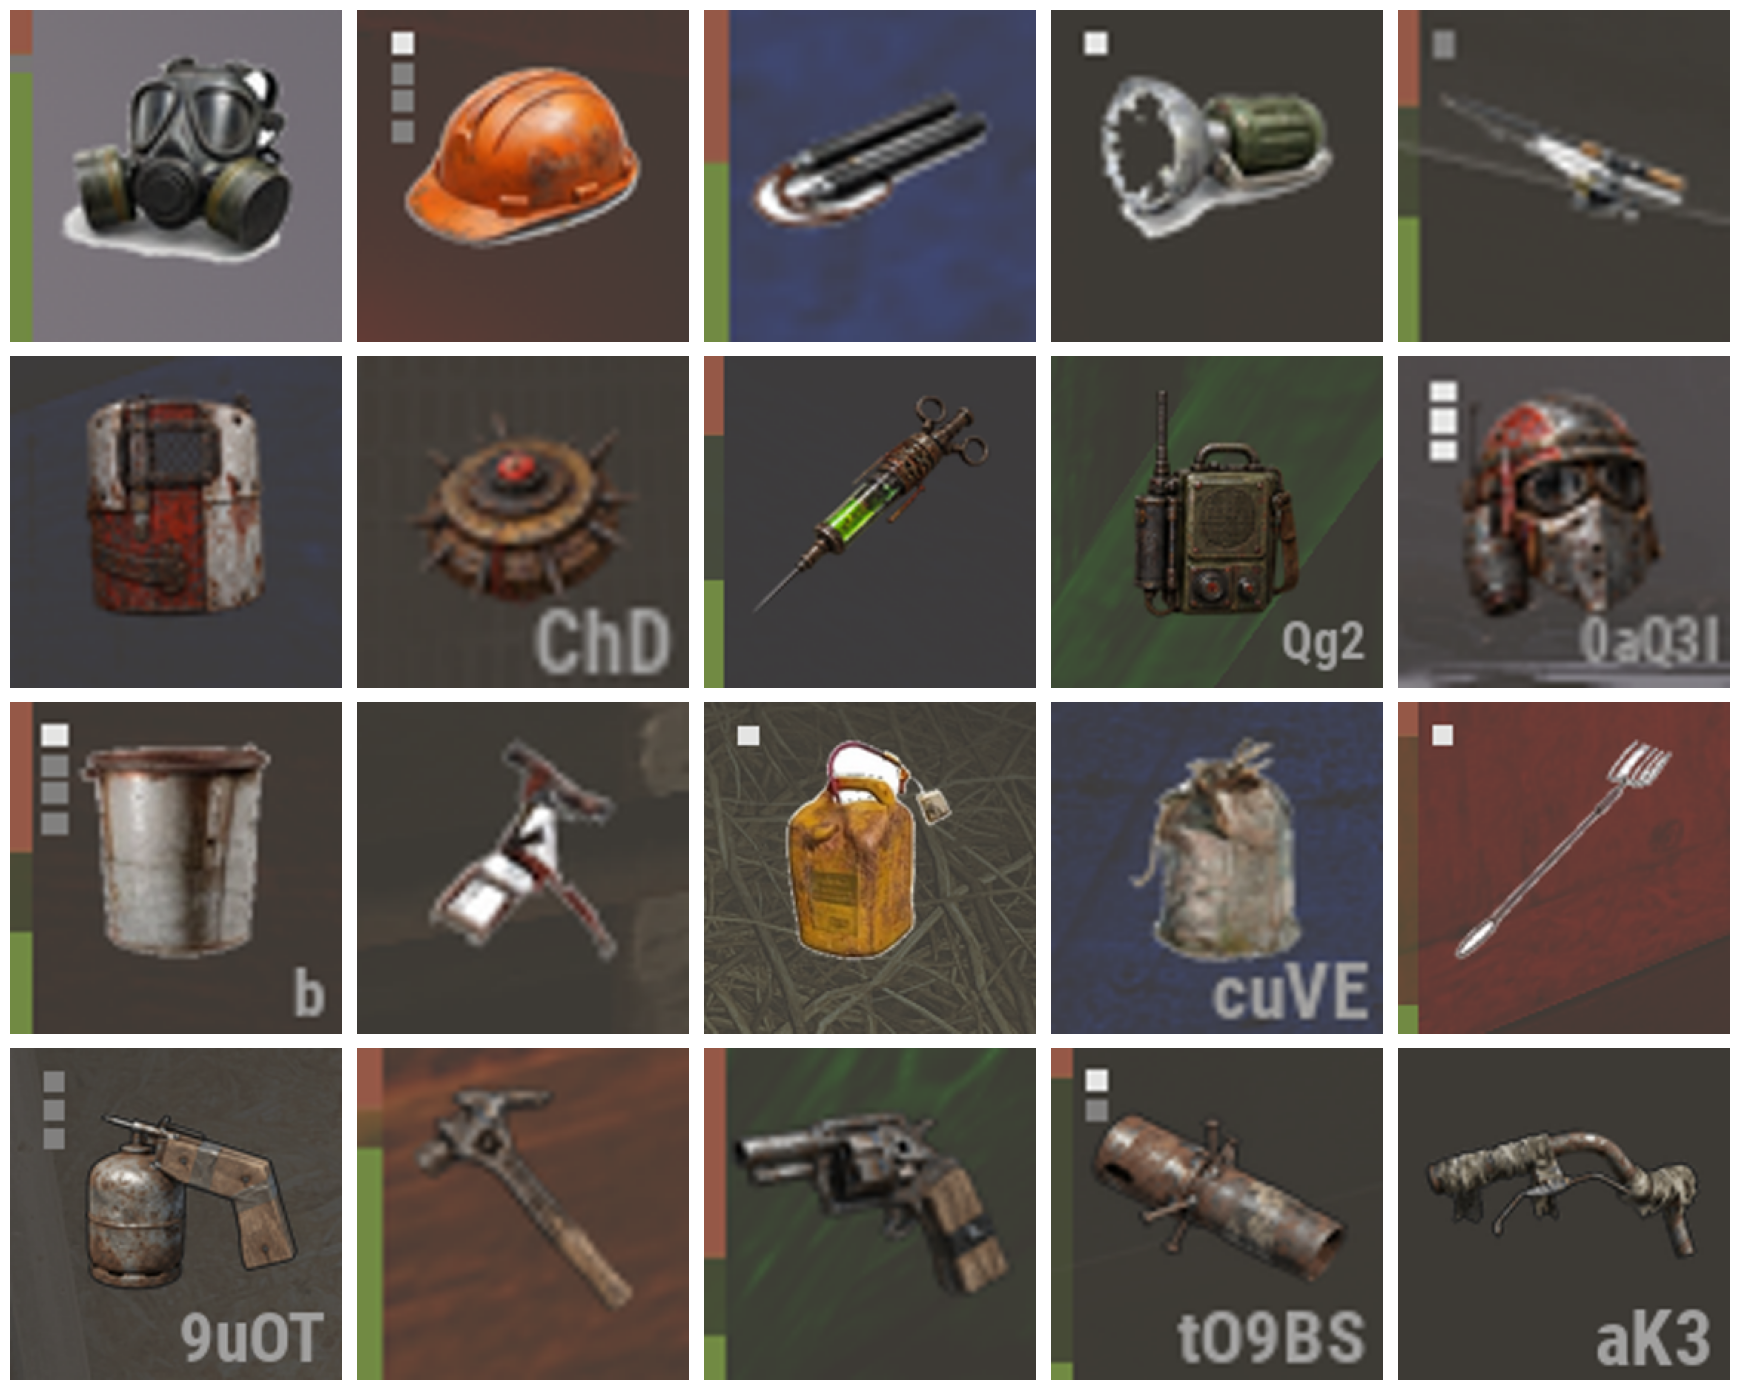

In [50]:
from torchvision.transforms.functional import to_pil_image

imgs = []

for i in range(0, fake_item_dataset_len, 5):
    imgs.append(to_pil_image(fake_item_dataset[i][0]))

show_grid(imgs, 5, 4)

In [51]:
from torch.utils.data import DataLoader

junk_loader  = DataLoader(fake_item_dataset,  batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

In [52]:
junk_embs, _ = compute_embeddings(lit_model.model, junk_loader)
junk_conf = (junk_embs @ centroids.t()).max(1).values
print(f"уверенность на мусоре: mean {junk_conf.mean():.3f}, max {junk_conf.max():.3f}")

уверенность на мусоре: mean 0.419, max 0.723


In [53]:
import torch

def threshold_table(preds, labels, confidence, thresholds=None, junk_conf=None):
    """
    Показывает компромисс при разных порогах уверенности.
      покрытие        — доля примеров, на которые модель ответила (не отказалась)
      точность        — точность среди отвеченных
      ошибок отсеч.   — сколько ошибок не прошло порог
      верных потеряно — сколько правильных ответов зря отсеклось
      мусора прошло   — сколько посторонних картинок прошло порог (если передан junk_conf)
    """
    correct = preds == labels
    n_wrong = (~correct).sum().item()
    if thresholds is None:
        thresholds = torch.arange(0.50, 0.95, 0.05)

    header = f"{'порог':>6} {'покрытие':>10} {'точность':>11} {'ошибок отсеч.':>15} {'верных потеряно':>17}"
    if junk_conf is not None:
        header += f" {'мусора прошло':>15}"
    print(header)

    for t in thresholds:
        answered = confidence >= t
        acc    = correct[answered].float().mean() * 100
        caught = ((~correct) & (~answered)).sum().item()   # ошибки, которые отсеклись
        lost   = (correct & (~answered)).sum().item()      # верные, потерянные зря

        row = (f"{t:6.2f} {answered.float().mean()*100:9.2f}% {acc:10.3f}% "
               f"{caught:>11}/{n_wrong} {lost:>16}")
        if junk_conf is not None:
            row += f" {(junk_conf >= t).sum().item():>14}/{len(junk_conf)}"
        print(row)

In [54]:
# Выводим таблицу ошибок для определения наиболее оптимального значения threshold
threshold_table(preds, labels, confidence,
                thresholds=torch.tensor([i/100 for i in range(65, 81)]),
                junk_conf=junk_conf)

 порог   покрытие    точность   ошибок отсеч.   верных потеряно   мусора прошло
  0.65     99.28%     99.904%          10/23               88              3/100
  0.66     99.14%     99.904%          10/23              107              3/100
  0.67     99.01%     99.911%          11/23              124              3/100
  0.68     98.90%     99.918%          12/23              138              3/100
  0.69     98.80%     99.926%          13/23              150              1/100
  0.70     98.62%     99.926%          13/23              175              1/100
  0.71     98.41%     99.933%          14/23              203              1/100
  0.72     98.14%     99.933%          14/23              240              1/100
  0.73     97.92%     99.940%          15/23              269              0/100
  0.74     97.65%     99.940%          15/23              305              0/100
  0.75     97.40%     99.947%          16/23              339              0/100
  0.76     97.08%     99.955%

В качестве порога уверенности выбрано значение **0.73**. Оно полностью отсекает fake-изображения — при более низких значениях мусор начинает просачиваться (одна картинка при 0.69–0.72, три при 0.65–0.68). Порог задерживает 15 из 23 ошибочных предсказаний, теряя 269 верных ответов (2.1% покрытия), а точность среди отвеченных случаев поднимается до 99.940%.

Повышать порог дальше невыгодно: переход к 0.76 стоит 112 дополнительных верных ответов ради всего двух пойманных ошибок, а после 0.76 число задержанных ошибок перестаёт расти вовсе (17 из 23), тогда как потери продолжают увеличиваться — до 605 верных ответов при пороге 0.80. Оставшиеся ошибки имеют высокую уверенность и лежат внутри распределения верных предсказаний, поэтому отсечь их порогом невозможно ни при какой разумной цене.

In [55]:
THRESHOLD = 0.73

# Экспорт модели

Сохраним модель в ONNX формат для удобного запуска на любой платформе и языке.

In [58]:
from pathlib import Path

MODEL_DIR = "/home/user/Documents/rust-items-detection/model"

Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

In [59]:
import torch

class EmbedOnly(torch.nn.Module):
    """Обёртка: только эмбеддинг, без ArcFace-головы."""
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model.embed(x)


model = lit_model.model.eval().cpu()
wrapper = EmbedOnly(model).eval()

dummy = torch.randn(1, 3, 224, 224) # размер входа (1 изображение, 3 канала RGB, 224x224 пикселя)

torch.onnx.export(
    wrapper, 
    dummy, 
    f"{MODEL_DIR}/item_recognizer.onnx",
    input_names=['image'],
    output_names=['embedding'],
    dynamic_axes={'image': {0: 'batch'},        # переменный размер батча
                  'embedding': {0: 'batch'}},
    opset_version=17,
    do_constant_folding=True,
)
print("экспортировано")

/tmp/ipykernel_17233/364644075.py:17: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


экспортировано


In [60]:
# Получить информацию о предметах, которые модель умеет предсказывать
def get_only_general_items_info_by_label(items_info):
    general_items_info_by_label = {}
    
    # Классы, которые модель не предсказывает (они были обобщены)
    generalized = set()
    for gener, classes in generalizing_classes.items():
        for c in classes:
            if (c == gener): continue
            generalized.add(c)

    # Список label-ов предмета с учётом обобщения классов
    for info in items_info:
        if (info["shortname"] in generalized):
            continue
        general_items_info_by_label[info["label"]] = {
            "itemid": info["itemid"],
            "shortname": info["shortname"],
            "Name": info["Name"],
            "Category": info["Category"],
        }
    return general_items_info_by_label

In [61]:
# информация о предмете по метке
general_items_info_by_label = get_only_general_items_info_by_label(items_info)

print("Количество информации о предметах по меткам:", len(general_items_info_by_label))
print("Количество уникальных меток:", ITEMS_UNIQUE_CLASSES_COUNT)

Количество информации о предметах по меткам: 1211
Количество уникальных меток: 1211


In [62]:
import json

# --- сохраняем дополнительные файлы модели ---

# 1) центроиды классов
torch.save(centroids, f"{MODEL_DIR}/centroids.pt")
np.save(f"{MODEL_DIR}/centroids.npy", centroids.numpy())      # для не-Python языков

# 2) маппинг индекс -> название предмета
json.dump(general_items_info_by_label,
          open(f"{MODEL_DIR}/class_mapping.json", "w"), ensure_ascii=False, indent=2)

# 3) параметры препроцессинга
json.dump({
    "input_size": [224, 224],
    "normalize": False,              # НЕТ Normalize — только деление на 255
    "channel_order": "RGB",
    "layout": "NCHW",                # [batch, channels, height, width]
    "threshold": THRESHOLD,          # порог уверенности
    "embedding_dim": 256,            # размерность вектора, который выдаёт модель (embeded_dim)
}, open(f"{MODEL_DIR}/class_mapping.json", "w"), indent=2)

In [64]:
import onnxruntime as ort
import numpy as np

# --- проверка (сравниваем выходы PyTorch и ONNX модели) ---

sess = ort.InferenceSession(f"{MODEL_DIR}/item_recognizer.onnx", providers=['CPUExecutionProvider'])

test_in = torch.randn(4, 3, 224, 224)
with torch.no_grad():
    torch_out = wrapper(test_in).numpy()
onnx_out = sess.run(None, {'image': test_in.numpy()})[0]

print("макс расхождение:", np.abs(torch_out - onnx_out).max())   # ожидаем ~1e-5

макс расхождение: 1.1920929e-06
